In [2]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_gas
importlib.reload(two_component_gas)
from two_component_gas import TwoComponentGas


In [105]:
gas = TwoComponentGas(
    element="87Rb",
    N_particles=(5e4, 5e4),
    N_grid=32,
    grid_size=(20e-6, 20e-6, 3e-6),
)

sigma = 3e-6 / gas.adim_length

psi1 = torch.exp(-(gas.X**2 + gas.Y**2 + gas.Z**2 * 100) / (2 * sigma**2))
psi2 = torch.exp(-(gas.X**2 + gas.Y**2 + gas.Z**2 * 100) / (2 * sigma**2))

gas.psi = torch.stack([psi1, psi2], dim=0)

print(gas.psi.shape)
print(gas.psik.shape)

print(torch.sum(torch.abs(gas.psi[0]) ** 2) * gas.dx * gas.dy * gas.dz)
print(torch.sum(torch.abs(gas.psi[1]) ** 2) * gas.dx * gas.dy * gas.dz)

torch.Size([2, 32, 32, 32])
torch.Size([2, 64, 64, 64])
tensor(1.0000, dtype=torch.float64)
tensor(1.0000, dtype=torch.float64)


In [3]:
import two_component_variable_gas
importlib.reload(two_component_variable_gas)
from two_component_variable_gas import TwoComponentGas

N1_initial = 5e4
N2_initial = 5e4

gas = TwoComponentGas(
    element="87Rb",
    N_particles=(N1_initial, N2_initial),
    N_grid=32,
    grid_size=(20e-6, 20e-6, 3e-6),
)

N_total = N1_initial + N2_initial

f1 = N1_initial / N_total
f2 = N2_initial / N_total

sigma_x = 3e-6 / gas.adim_length
sigma_y = 3e-6 / gas.adim_length
sigma_z = 3e-7 / gas.adim_length

psi_shape = torch.exp(
    -0.5 * (
        (gas.X / sigma_x)**2
        + (gas.Y / sigma_y)**2
        + (gas.Z / sigma_z)**2
    )
)

psi1 = torch.sqrt(torch.as_tensor(f1, device=gas.device)) * psi_shape
psi2 = torch.sqrt(torch.as_tensor(f2, device=gas.device)) * psi_shape

gas.psi = torch.stack((psi1, psi2))

print(gas.component_fractions)
print(gas.component_numbers)

tensor([0.5000, 0.5000], dtype=torch.float64)
tensor([50000., 50000.], dtype=torch.float64)


In [5]:
import potentials3D
importlib.reload(potentials3D)
from potentials3D import TwoComponentContact, Trap3D, TwoComponentVariableContact

import energy_callback
importlib.reload(energy_callback)
from energy_callback import TwoComponentEnergyMonitor3D

a = 100
contact = TwoComponentVariableContact(a_s = a)
trap = Trap3D(omegax = 400, omegay = 400, omegaz = 4000)

# Manually initialize contact before reading _g1/_g2
contact.set_gas(gas)
contact.on_propagation_begin()

energy_cb = TwoComponentEnergyMonitor3D(
    g11=contact._g,
    g22=contact._g,
    g12=0,
    V1=trap,
    V2=trap,
    compute_every=100,
    print_every=1000,
)

gas.ground_state(potentials=[trap, contact], N_iterations=5e3, callbacks=[energy_cb])

Ground state:   0%|          | 0/5000 [00:00<?]

epoch        0 | E = 1.201789071579e+02 | Ekin = 2.731667e+00 | Epot = 7.873066e+01 | Eint = 3.871658e+01 | N1 = 5.000000e-01 | N2 = 5.000000e-01 | dpsi = nan
epoch     1000 | E = 1.129981201636e+02 | Ekin = 3.442292e+00 | Epot = 6.722089e+01 | Eint = 4.233494e+01 | N1 = 5.000000e-01 | N2 = 5.000000e-01 | dpsi = 7.746e-06
epoch     2000 | E = 1.129981193808e+02 | Ekin = 3.442290e+00 | Epot = 6.722087e+01 | Eint = 4.233496e+01 | N1 = 5.000000e-01 | N2 = 5.000000e-01 | dpsi = 1.142e-09
epoch     3000 | E = 1.129981193807e+02 | Ekin = 3.442290e+00 | Epot = 6.722087e+01 | Eint = 4.233496e+01 | N1 = 5.000000e-01 | N2 = 5.000000e-01 | dpsi = 1.688e-13
epoch     4000 | E = 1.129981193807e+02 | Ekin = 3.442290e+00 | Epot = 6.722087e+01 | Eint = 4.233496e+01 | N1 = 5.000000e-01 | N2 = 5.000000e-01 | dpsi = 9.275e-16


In [10]:
print(torch.sum(torch.abs(gas.psi[0]) ** 2) * gas.dx * gas.dy * gas.dz)
print(torch.sum(torch.abs(gas.psi[1]) ** 2) * gas.dx * gas.dy * gas.dz)

tensor(0.5000, dtype=torch.float64)
tensor(0.5000, dtype=torch.float64)


In [31]:
import pickle
import os

name = '3d_trap.pkl'
if not os.path.exists(name):
    with open(name, "wb") as f:
        pickle.dump(gas, f)
else:
    with open(name, "rb") as f:
        gas = pickle.load(f)

test


In [39]:
print(gas.density[0][:,:,16].size())
print(gas.X.size())

torch.Size([32, 32])
torch.Size([32, 32, 32])


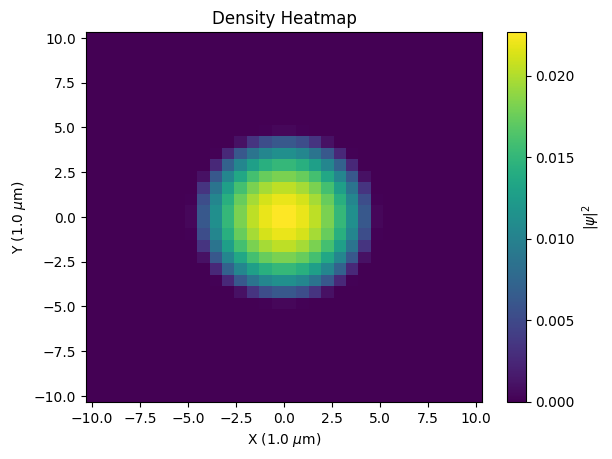

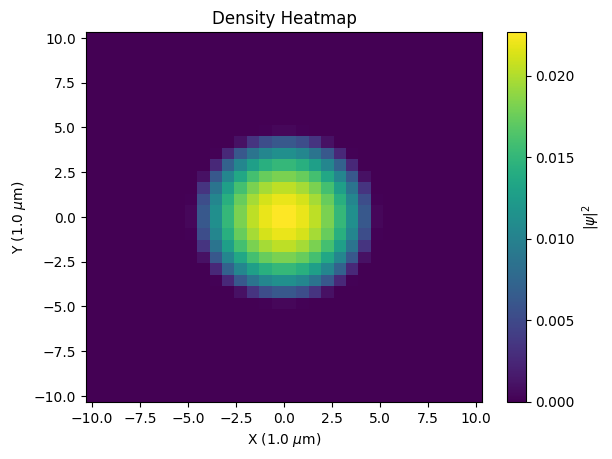

In [6]:
import matplotlib.pyplot as plt

for i in range(0, 2):
    plt.pcolormesh(gas.X[:,:,16], gas.Y[:,:,16], gas.density[i][:,:,16], shading='auto')
    plt.colorbar(label=r'$|\psi|^2$')
    plt.xlabel('X (' + str(gas.adim_length*1e6) + r' $\mu$m)')
    plt.ylabel('Y (' + str(gas.adim_length*1e6) + r' $\mu$m)')
    plt.title('Density Heatmap')
    plt.show()

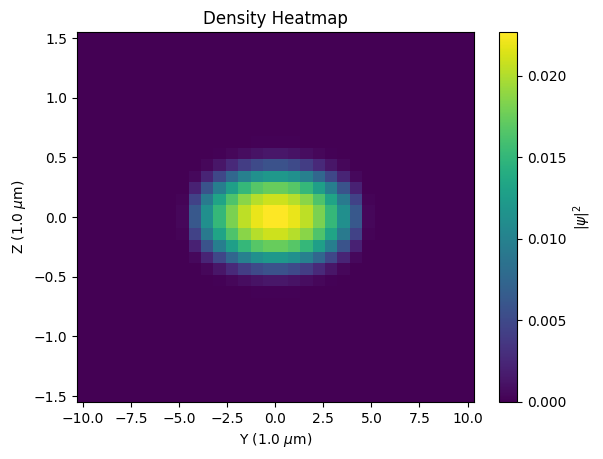

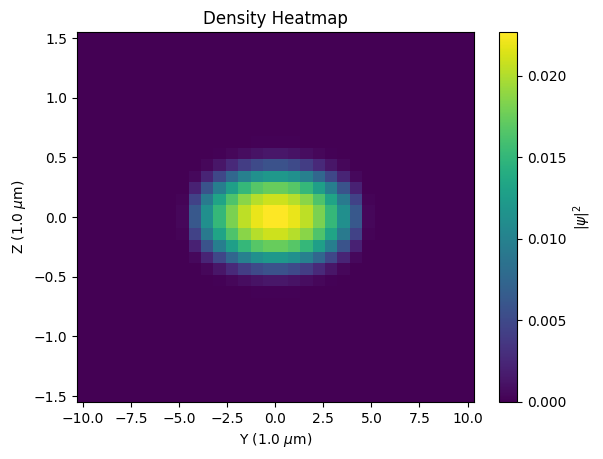

In [7]:
import matplotlib.pyplot as plt

for i in range(0, 2):
    plt.pcolormesh(gas.Y[:,16,:], gas.Z[:,16,:], gas.density[i][:,16,:], shading='auto')
    plt.colorbar(label=r'$|\psi|^2$')
    plt.xlabel('Y (' + str(gas.adim_length*1e6) + r' $\mu$m)')
    plt.ylabel('Z (' + str(gas.adim_length*1e6) + r' $\mu$m)')
    plt.title('Density Heatmap')
    plt.show()

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.constants as spconsts


def get_base_gas(gas):
    """
    Works for either:
        gas = Gas(...)
    or:
        gas = TwoComponentGas(...)
    """
    return gas.gas1 if hasattr(gas, "gas1") else gas


def get_component_N(gas, component=0):
    if hasattr(gas, "gas1"):
        return gas.gas1.N_particles if component == 0 else gas.gas2.N_particles
    return gas.N_particles


def thomas_fermi_3d_parameters(
    gas,
    omega_x,
    omega_y,
    omega_z,
    a_s_bohr=100,
    component=0,
):
    """
    Returns the dimensionless 3D TF parameters for one component.

    Assumes:
        psi is normalized to int |psi|^2 dX dY dZ = 1
        g = 4*pi*N*a_s/ell
        V = 1/2 * [(omega_x/omega_l)^2 X^2
                 + (omega_y/omega_l)^2 Y^2
                 + (omega_z/omega_l)^2 Z^2]
    """
    base = get_base_gas(gas)

    N = get_component_N(gas, component)
    ell = base.adim_length
    omega_l = base.adim_pulse

    a0 = spconsts.codata.value("Bohr radius")
    a_s = a_s_bohr * a0

    # Correct full-3D dimensionless contact coefficient
    g_dim = 4 * np.pi * N * a_s / ell

    lam_x = omega_x / omega_l
    lam_y = omega_y / omega_l
    lam_z = omega_z / omega_l

    # Dimensionless TF chemical potential
    # mu = 1/2 * [15*g*lambda_x*lambda_y*lambda_z/(4*pi)]^(2/5)
    mu_dim = 0.5 * (
        15 * g_dim * lam_x * lam_y * lam_z / (4 * np.pi)
    ) ** (2 / 5)

    R_x = np.sqrt(2 * mu_dim) / lam_x
    R_y = np.sqrt(2 * mu_dim) / lam_y
    R_z = np.sqrt(2 * mu_dim) / lam_z

    return {
        "g_dim": g_dim,
        "mu_dim": mu_dim,
        "R_x_dim": R_x,
        "R_y_dim": R_y,
        "R_z_dim": R_z,
        "R_x_um": R_x * ell * 1e6,
        "R_y_um": R_y * ell * 1e6,
        "R_z_um": R_z * ell * 1e6,
    }


def plot_x_slice_against_tf(
    gas,
    omega_x,
    omega_y,
    omega_z,
    a_s_bohr=100,
    component=0,
    normalize_peak=False,
):
    """
    Plots numerical |psi_component(x,0,0)|^2 against the 3D TF central slice.

    Use component=0 for psi1, component=1 for psi2.
    """
    base = get_base_gas(gas)

    params = thomas_fermi_3d_parameters(
        gas,
        omega_x=omega_x,
        omega_y=omega_y,
        omega_z=omega_z,
        a_s_bohr=a_s_bohr,
        component=component,
    )

    g_dim = params["g_dim"]
    mu_dim = params["mu_dim"]

    lam_x = omega_x / base.adim_pulse
    lam_y = omega_y / base.adim_pulse
    lam_z = omega_z / base.adim_pulse

    # Numerical density for one component.
    psi = gas.psi[component] if hasattr(gas, "gas1") else gas.psi
    n_num = torch.abs(psi) ** 2

    # Central indices.
    iy0 = torch.argmin(torch.abs(base.y)).item()
    iz0 = torch.argmin(torch.abs(base.z)).item()

    # Because meshgrid(..., indexing="xy"), the x-line is n[iy0, :, iz0].
    x_dim = base.x.detach().cpu().numpy()
    x_um = x_dim * base.adim_length * 1e6

    n_num_line = n_num[iy0, :, iz0].detach().cpu().numpy()

    # TF central density line: y = 0, z = 0.
    V_line = 0.5 * (lam_x**2) * x_dim**2
    n_tf_line = np.maximum((mu_dim - V_line) / g_dim, 0.0)

    if normalize_peak:
        n_num_line = n_num_line / np.max(n_num_line)
        n_tf_line = n_tf_line / np.max(n_tf_line)
        ylabel = "density / peak density"
    else:
        ylabel = r"$|\psi(x,0,0)|^2$"

    plt.figure(figsize=(7, 4.5))
    plt.plot(
        x_um,
        n_num_line,
        label=f"numerical component {component + 1}",
        linewidth=2,
    )
    plt.plot(
        x_um,
        n_tf_line,
        "--",
        label="Thomas-Fermi",
        linewidth=2,
    )

    plt.axvline(params["R_x_um"], linestyle=":", linewidth=1)
    plt.axvline(-params["R_x_um"], linestyle=":", linewidth=1)

    plt.xlabel(r"$x$ [$\mu$m]")
    plt.ylabel(ylabel)
    plt.title(r"Central density slice: $|\psi(x,0,0)|^2$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Useful diagnostics
    dV = base.dx * base.dy * base.dz
    norm_num = torch.sum(n_num) * dV

    V_3d = 0.5 * (
        (lam_x**2) * base.X**2
        + (lam_y**2) * base.Y**2
        + (lam_z**2) * base.Z**2
    )
    n_tf_3d = torch.clamp((mu_dim - V_3d) / g_dim, min=0.0)
    norm_tf_discrete = torch.sum(n_tf_3d) * dV

    print("TF comparison parameters")
    print("------------------------")
    print(f"g_dim          = {params['g_dim']:.6e}")
    print(f"mu_dim         = {params['mu_dim']:.6e}")
    print(f"R_x            = {params['R_x_um']:.4f} um")
    print(f"R_y            = {params['R_y_um']:.4f} um")
    print(f"R_z            = {params['R_z_um']:.4f} um")
    print(f"numerical norm = {norm_num.detach().cpu().item():.8f}")
    print(f"TF grid norm   = {norm_tf_discrete.detach().cpu().item():.8f}")

    return params

C:\Users\kevin\AppData\Local\Temp\ipykernel_35176\1748156892.py:47: DeprecationWarning: Please import `value` from the `scipy.constants` namespace; the `scipy.constants.codata` namespace is deprecated and will be removed in SciPy 2.0.0.
  a0 = spconsts.codata.value("Bohr radius")


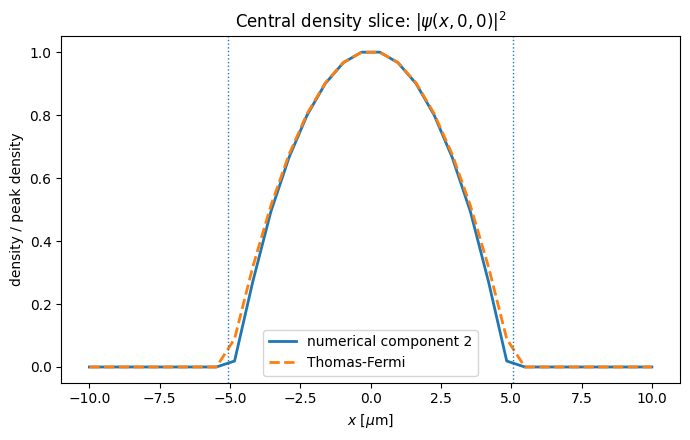

TF comparison parameters
------------------------
g_dim          = 3.324918e+03
mu_dim         = 1.523188e+02
R_x            = 5.0694 um
R_y            = 5.0694 um
R_z            = 0.5069 um
numerical norm = 0.50000000
TF grid norm   = 1.00068319


In [9]:
omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000

params = plot_x_slice_against_tf(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
    a_s_bohr=100,
    component=1,
    normalize_peak=True,
)

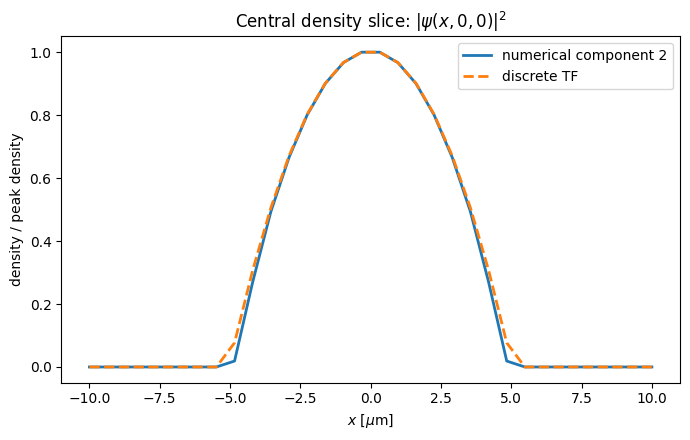

Discrete TF diagnostics
-----------------------
component       = 2
g used          = 3.324918e+03
mu_TF           = 1.522775e+02
numerical norm  = 1.00000000
TF norm         = 1.00000000
peak numerical  = 4.533299e-02
peak TF         = 4.501053e-02


In [112]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def discrete_tf_density_from_actual_potential(gas, V, g, component=0):
    """
    Build a discrete 3D TF density using the actual potential array V and
    the actual dimensionless contact coefficient g.

    Assumes component wavefunction is normalized to:
        integral |psi_j|^2 dX dY dZ = 1
    which matches your Gas.psi setter.
    """
    base = gas.gas1 if hasattr(gas, "gas1") else gas

    dV = base.dx * base.dy * base.dz

    # We solve for mu such that:
    # sum(max((mu - V)/g, 0)) * dV = 1
    V_min = torch.min(V).detach()
    V_max = torch.max(V).detach()

    mu_lo = V_min
    mu_hi = V_max + g / (dV * V.numel())

    # Increase upper bound until TF norm exceeds 1
    for _ in range(100):
        n_hi = torch.clamp((mu_hi - V) / g, min=0.0)
        norm_hi = torch.sum(n_hi) * dV
        if norm_hi > 1.0:
            break
        mu_hi = 2.0 * mu_hi + 1.0

    # Bisection for chemical potential
    for _ in range(100):
        mu_mid = 0.5 * (mu_lo + mu_hi)
        n_mid = torch.clamp((mu_mid - V) / g, min=0.0)
        norm_mid = torch.sum(n_mid) * dV

        if norm_mid < 1.0:
            mu_lo = mu_mid
        else:
            mu_hi = mu_mid

    mu = 0.5 * (mu_lo + mu_hi)
    n_tf = torch.clamp((mu - V) / g, min=0.0)

    return n_tf, mu


def plot_x_slice_against_discrete_tf(
    gas,
    trap,
    contact,
    component=1,
    normalize_peak=True,
):
    """
    component=0 for psi1, component=1 for psi2.
    """

    base = gas.gas1 if hasattr(gas, "gas1") else gas

    # Make sure trap/contact are initialized.
    # If you already ran ground_state with these objects, this is usually harmless.
    trap.set_gas(gas)
    trap.on_propagation_begin()

    contact.set_gas(gas)
    contact.on_propagation_begin()

    # Actual potential used by the trap
    V = trap.get_potential(*gas.coordinates)

    # Pick the actual g used for this component
    if component == 0:
        g = contact._g1 if hasattr(contact, "_g1") else contact._g
    else:
        g = contact._g2 if hasattr(contact, "_g2") else contact._g

    # Numerical density
    psi = gas.psi[component] if hasattr(gas, "gas1") else gas.psi
    n_num = torch.abs(psi)**2

    # Discrete TF density using same V and same g
    n_tf, mu_tf = discrete_tf_density_from_actual_potential(
        gas=gas,
        V=V,
        g=g,
        component=component,
    )

    # Central indices
    ix0 = torch.argmin(torch.abs(base.x)).item()
    iy0 = torch.argmin(torch.abs(base.y)).item()
    iz0 = torch.argmin(torch.abs(base.z)).item()

    # Because your meshgrid uses indexing="xy", the tensor order is [y, x, z].
    x_um = base.x.detach().cpu().numpy() * base.adim_length * 1e6

    n_num_line = n_num[iy0, :, iz0].detach().cpu().numpy()
    n_tf_line = n_tf[iy0, :, iz0].detach().cpu().numpy()

    if normalize_peak:
        n_num_line = n_num_line / np.max(n_num_line)
        n_tf_line = n_tf_line / np.max(n_tf_line)
        ylabel = "density / peak density"
    else:
        ylabel = r"$|\psi(x,0,0)|^2$"

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_um, n_num_line, label=f"numerical component {component + 1}", linewidth=2)
    plt.plot(x_um, n_tf_line, "--", label="discrete TF", linewidth=2)
    plt.xlabel(r"$x$ [$\mu$m]")
    plt.ylabel(ylabel)
    plt.title(r"Central density slice: $|\psi(x,0,0)|^2$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    dV = base.dx * base.dy * base.dz
    norm_num = torch.sum(n_num) * dV
    norm_tf = torch.sum(n_tf) * dV

    print("Discrete TF diagnostics")
    print("-----------------------")
    print(f"component       = {component + 1}")
    print(f"g used          = {float(g):.6e}")
    print(f"mu_TF           = {mu_tf.detach().cpu().item():.6e}")
    print(f"numerical norm  = {norm_num.detach().cpu().item():.8f}")
    print(f"TF norm         = {norm_tf.detach().cpu().item():.8f}")
    print(f"peak numerical  = {torch.max(n_num).detach().cpu().item():.6e}")
    print(f"peak TF         = {torch.max(n_tf).detach().cpu().item():.6e}")

    return n_tf, mu_tf

n_tf, mu_tf = plot_x_slice_against_discrete_tf(
    gas=gas,
    trap=trap,
    contact=contact,
    component=1,        # component 2
    normalize_peak=True,
)

In [94]:
trap.set_gas(gas)
trap.on_propagation_begin()

V = trap.get_potential(*gas.coordinates)

base = gas.gas1 if hasattr(gas, "gas1") else gas

target = (base.X - 1.0)**2 + base.Y**2 + base.Z**2
idx = torch.argmin(target.reshape(-1)).item()

V_at_1um = V.reshape(-1)[idx].detach().cpu().item()

omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000
V_expected = (0.5 * (omega_x / base.adim_pulse * base.X.reshape(-1)[idx])**2 + 
              0.5 * (omega_y / base.adim_pulse * base.Y.reshape(-1)[idx])**2 + 
              0.5 * (omega_z / base.adim_pulse * base.Z.reshape(-1)[idx])**2)

print("V at x = 1 um:", V_at_1um)
print("Expected:", V_expected)

V at x = 1 um: 67.84274305179245
Expected: tensor(67.8427, dtype=torch.float64)


In [84]:
target = (base.X - 1.0)**2 + base.Y**2 + base.Z**2
print(target.size())
torch.argmin(target).item()

torch.Size([32, 32, 32])


15919

In [93]:
print(base.X.reshape(-1)[idx])
print(base.Y.reshape(-1)[idx])
print(base.Z.reshape(-1)[idx])

tensor(0.9677, dtype=torch.float64)
tensor(-0.3226, dtype=torch.float64)
tensor(-0.3226, dtype=torch.float64)


In [80]:
print(gas.adim_pulse)
print(gas.gas1.adim_pulse)

729.9747045504482
729.9747045504482
